<a href="https://colab.research.google.com/github/seongwoojang1123/Effusion-OSA-TMD/blob/main/4_feature_significance_analysis_Effusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.patheffects as pe
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.path import Path
from math import ceil
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import pearsonr
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import StandardScaler

file_path = '/content/drive/MyDrive/Effusion OSA TMD/20250831_Effusion_TMD_Pain_Data.xlsx'

df = pd.read_excel(file_path, sheet_name='20250830_20250829_20250226_2024')

Alluvial

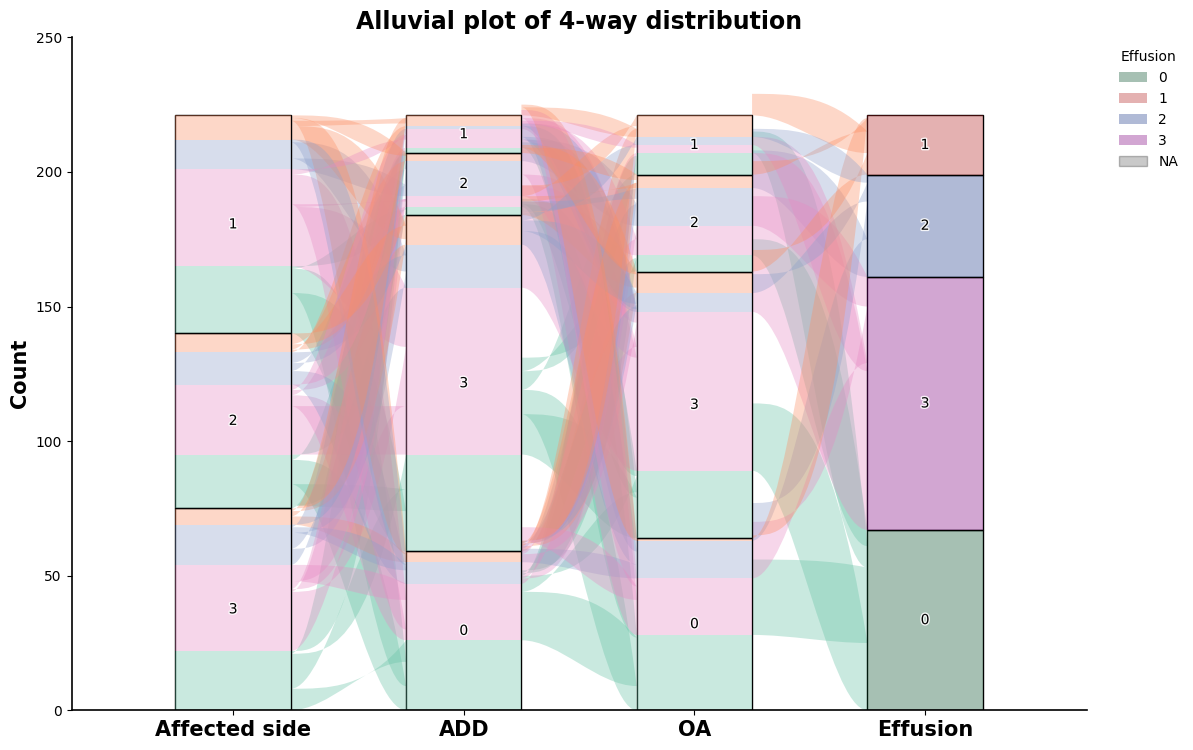

In [3]:
cols = ["Affected side_123", "ADD_123", "OA_123", "Effusion_123"]

# 기본 팔레트(리본/기본 바 색)
effusion_palette = {"0":"#66c2a5","1":"#fc8d62","2":"#8da0cb","3":"#e78ac3","NA":"#ffffff"}
effusion_edge = "#404040"
seg_alpha = 0.35  # 리본/바 색띠 투명도

# --- 헬퍼: 색 어둡게 ---
def darken(hexcolor, factor=0.7):
    # factor < 1 이면 어두워짐 (0.8 = 20% darker)
    if hexcolor.startswith("#") and len(hexcolor) == 7:
        r = int(hexcolor[1:3], 16)
        g = int(hexcolor[3:5], 16)
        b = int(hexcolor[5:7], 16)
        r = int(max(0, min(255, r * factor)))
        g = int(max(0, min(255, g * factor)))
        b = int(max(0, min(255, b * factor)))
        return "#{:02x}{:02x}{:02x}".format(r, g, b)
    return hexcolor

# 4번째 바(Effusion_123)만 더 진한 팔레트
effusion_palette_dark = {
    "0": "#004d26",   # 진한 초록 (Dark Green)
    "1": "#b22222",   # 진한 빨강/주황 (Firebrick)
    "2": "#1e3a8a",   # 진한 파랑 (Navy/Indigo)
    "3": "#800080",   # 진한 보라 (Purple)
    "NA": "#666666"   # NA는 진한 회색
}

# ---- 데이터 전처리 ----
df_alluv = df.copy()
for c in cols:
    df_alluv[c] = df_alluv[c].where(df_alluv[c].notna(), "NA").astype(str)

# ---- 쌓임 순서 ----
order_map = {
    "Affected side_123": ["3","2","1","0","NA"],  # 아래→위: 3,2,1
    "ADD_123":           ["0","3","2","1","NA"],  # 아래→위: 0,3,2,1
    "OA_123":            ["0","3","2","1","NA"],
    "Effusion_123":      ["0","3","2","1","NA"]
}
eff_order = ["0","3","2","1","NA"]

def ordered_levels(c, counts_dict):
    base = order_map.get(c, ["0","1","2","3","NA"])
    ordered = [lv for lv in base if lv in counts_dict]
    rest = [lv for lv in counts_dict if lv not in base]
    return ordered + sorted(rest)

# ---- 카운트/블록 범위 ----
col_counts = {c: df_alluv[c].value_counts(dropna=False).to_dict() for c in cols}
max_total = max(sum(col_counts[c].values()) for c in cols)
block_ranges = {}
for c in cols:
    y = 0
    for lv in ordered_levels(c, col_counts[c]):
        h = col_counts[c][lv]
        block_ranges[(c, lv)] = (y, y + h)
        y += h

# ---- 바 내부 색띠 높이/시작위치 ----
segment_heights, segment_start = {}, {}
for c in cols:
    for lv in ordered_levels(c, col_counts[c]):
        sub = df_alluv[df_alluv[c]==lv][cols[-1]].value_counts(dropna=False).to_dict()
        sh = {ec: int(sub.get(ec, 0)) for ec in eff_order}
        segment_heights[(c, lv)] = sh
        y0, _ = block_ranges[(c, lv)]
        ycur, off = y0, {}
        for ec in eff_order:
            off[ec] = ycur
            ycur += sh[ec]
        segment_start[(c, lv)] = off

used_offsets = {(c, lv, ec): 0 for c in cols for lv in col_counts[c] for ec in eff_order}

# ---- 단계 간 흐름(리본) ----
flows = {}
for s in range(len(cols)-1):
    left, right = cols[s], cols[s+1]
    keys = [left, right] + ([] if right==cols[-1] else [cols[-1]])
    keys = list(dict.fromkeys(keys))
    tmp = df_alluv.groupby(keys, dropna=False, sort=False).size().reset_index(name="count")
    flows[(left, right)] = tmp

def ribbon(ax, x0, x1, y0a, y0b, y1a, y1b, color, alpha):
    verts = [(x0,y0a),(x0+0.33*(x1-x0),y0a),(x0+0.66*(x1-x0),y1a),(x1,y1a),
             (x1,y1b),(x0+0.66*(x1-x0),y0b),(x0+0.33*(x1-x0),y0b),(x0,y0b),(x0,y0a)]
    codes = [Path.MOVETO,Path.CURVE4,Path.CURVE4,Path.CURVE4,
             Path.LINETO,Path.CURVE4,Path.CURVE4,Path.CURVE4,Path.CLOSEPOLY]
    ax.add_patch(PathPatch(Path(verts,codes), facecolor=color, edgecolor="none", alpha=alpha, zorder=1))

# ---- 그리기 ----
fig, ax = plt.subplots(figsize=(12, 7.6))   # <<< (1) 사이즈 조정
x_positions = np.arange(len(cols))

# (a) 바 아웃라인 + 내부 색띠
for i, c in enumerate(cols):
    # 이 바에 사용할 팔레트 (4번째 바만 더 진하게)
    bar_palette = effusion_palette_dark if c == "Effusion_123" else effusion_palette
    for lv in ordered_levels(c, col_counts[c]):
        y0, y1 = block_ranges[(c, lv)]
        # 외곽선(검정색)  <<< (3)
        ax.add_patch(Rectangle((i-0.25, y0), 0.5, (y1-y0),
                               facecolor='none', edgecolor="black", linewidth=1, zorder=2))
        # 내부 색띠
        for ec in eff_order:
            h = segment_heights[(c, lv)][ec]
            if h <= 0:
                continue
            ax.add_patch(Rectangle((i-0.25, segment_start[(c, lv)][ec]), 0.5, h,
                                   facecolor=bar_palette.get(ec, "#cccccc"),
                                   edgecolor="none", alpha=seg_alpha, zorder=2))
        # 중앙 숫자(검정)  <<< (3)
        if (y1-y0) >= 12:
            ax.text(i, (y0+y1)/2, lv, ha="center", va="center", fontsize=10,
                    color="black",
                    path_effects=[pe.withStroke(linewidth=2, foreground="white", alpha=0.85)],
                    zorder=3)

# (b) 리본 (색은 기본 팔레트 유지)
for s in range(len(cols)-1):
    left, right = cols[s], cols[s+1]
    x0, x1 = x_positions[s] + 0.25, x_positions[s+1] - 0.25
    tmp = flows[(left, right)]
    for _, row in tmp.iterrows():
        lv_l, lv_r = str(row[left]), str(row[right])
        eff_cat = str(row[cols[-1]] if cols[-1] in row.index else row[right])
        cnt = int(row["count"])
        y0a = segment_start[(left, lv_l)][eff_cat]  + used_offsets[(left, lv_l, eff_cat)]
        y0b = y0a + cnt
        y1a = segment_start[(right, lv_r)][eff_cat] + used_offsets[(right, lv_r, eff_cat)]
        y1b = y1a + cnt
        ribbon(ax, x0, x1, y0a, y0b, y1a, y1b,
               color=effusion_palette.get(eff_cat, "#cccccc"), alpha=seg_alpha)
        used_offsets[(left, lv_l, eff_cat)]  += cnt
        used_offsets[(right, lv_r, eff_cat)] += cnt

# (c) 축/격자/범례  <<< (3) 라인 모두 검정
y_step = 50
ymax = max(200, y_step * ceil(max_total / y_step))
ax.set_ylim(0, ymax); ax.set_xlim(-0.7, len(cols)-0.3)
ax.set_axisbelow(True)
ax.set_yticks(np.arange(0, ymax+1, y_step))
ax.grid(which="major", axis="y", linestyle="-", linewidth=0.8, color="white")    # y-그리드 검정
for x in x_positions:
    ax.axvline(x=x, ymin=0, ymax=1, color="white", linewidth=0.8, zorder=0)     # 세로선 검정
for spine in ["left","bottom"]:
    ax.spines[spine].set_visible(True); ax.spines[spine].set_linewidth(1.2); ax.spines[spine].set_color("black")
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

ax.set_xticks(x_positions)
ax.set_xticklabels([c.replace("_123", "") for c in cols],
                   fontsize=15, fontweight="bold", color="black")
ax.set_ylabel("Count", fontsize=15, fontweight="bold", color="black")
ax.set_title("Alluvial plot of 4-way distribution",
             fontsize=17, fontweight="bold", color="black")

#ax.set_xticks(x_positions); ax.set_xticklabels(cols, fontsize=15, fontweight="bold", color="black")
#ax.set_ylabel("Count", fontsize=15, fontweight="bold", color="black")
#ax.set_title("Alluvial plot of 4-way distribution", fontsize=17, fontweight="bold", color="black")

# 범례(바깥) – 기본 팔레트, 동일 투명도
legend_keys = ["0","1","2","3","NA"]
legend_handles = [Rectangle((0,0),1,1,
                            facecolor=(effusion_palette_dark[k] if c=="Effusion_123" else effusion_palette[k]),
                            edgecolor=effusion_edge if k=="NA" else "none",
                            alpha=seg_alpha) for k in legend_keys]
ax.legend(legend_handles, legend_keys, title="Effusion",
          loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
fig.subplots_adjust(right=0.82)

plt.tight_layout()
plt.show()


Correlation Matrix

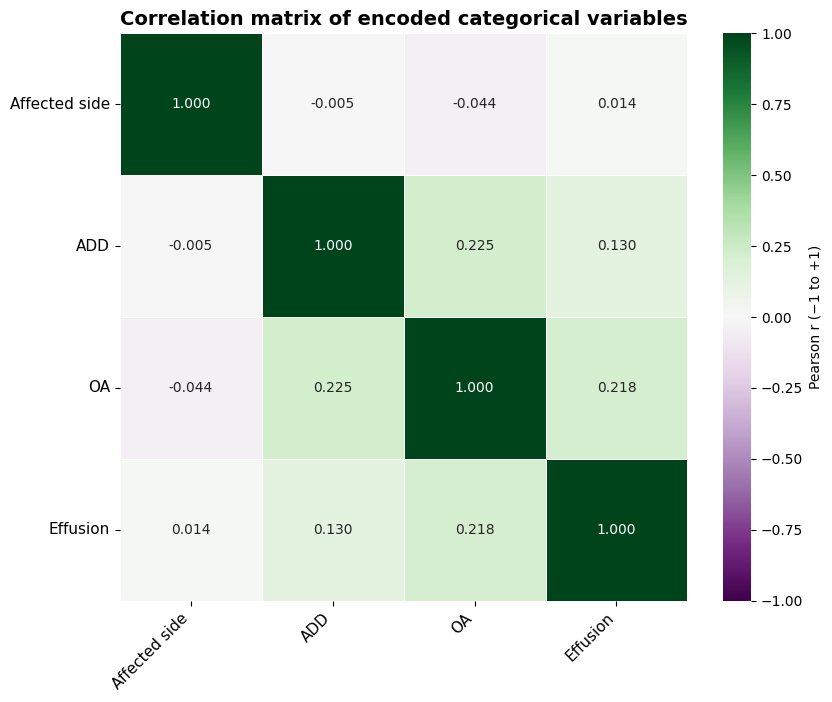

In [4]:

# --- 사용 컬럼 (이미 cols가 있다면 이 줄은 생략 가능) ---
# cols = ["Affected side_123", "ADD_123", "OA_123", "Effusion_123"]

# --- 카테고리 변수 숫자 인코딩 ---
df_encoded = df_alluv.copy()
for c in cols:
    le = LabelEncoder()
    df_encoded[c] = le.fit_transform(df_encoded[c].astype(str))

# --- 상관계수(피어슨) 계산 ---
corr = df_encoded[cols].corr(method="pearson").clip(-1, 1)

# --- 라벨에서 끝의 '_숫자' 꼬리표 제거 (예: 'OA_123' -> 'OA') ---
def clean_name(x):
    return re.sub(r'_\d+$', '', x)

corr.index   = [clean_name(x) for x in corr.index]
corr.columns = [clean_name(x) for x in corr.columns]

# --- 컬러맵: 초록-보라(그린-퍼플) 발산형, 0을 중앙으로 고정 ---
cmap = sns.color_palette("PRGn", as_cmap=True)  # purple–green diverging
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

# --- 히트맵 시각화 ---
plt.figure(figsize=(8.5, 7))
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",               # 소수점 셋째 자리까지
    cmap=cmap,
    norm=norm,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor="white",
    square=True,
    cbar=True,
    cbar_kws={"label": "Pearson r (−1 to +1)"}
)

# 축/제목 스타일
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
plt.title("Correlation matrix of encoded categorical variables", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


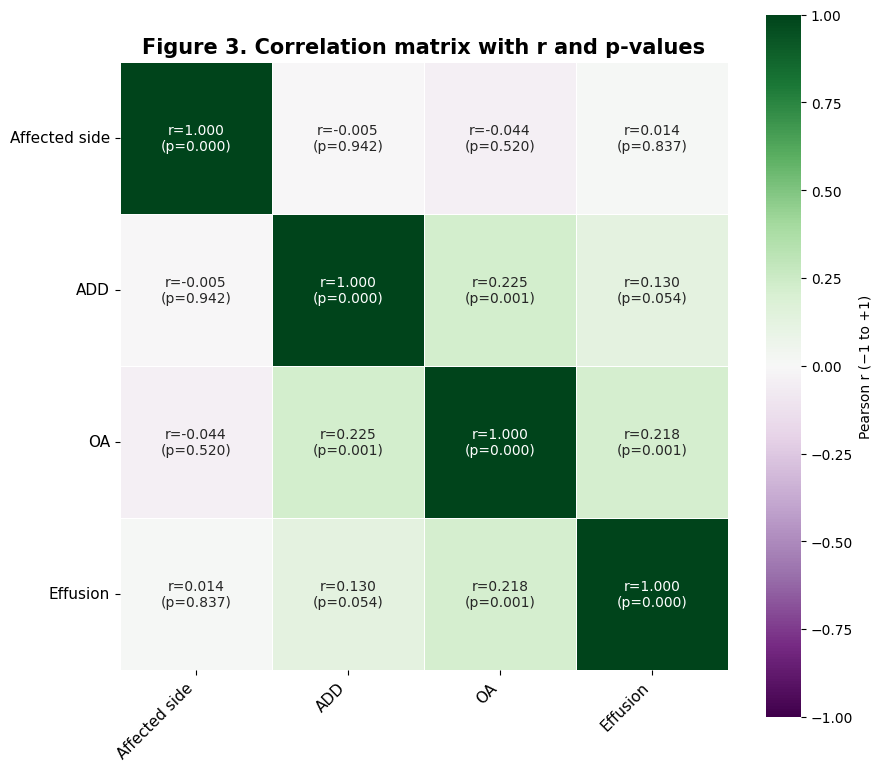

In [8]:
# --- 카테고리 변수 숫자 인코딩 ---
df_encoded = df_alluv.copy()
for c in cols:
    le = LabelEncoder()
    df_encoded[c] = le.fit_transform(df_encoded[c].astype(str))

# --- 상관계수 & p-value 계산 ---
corr = df_encoded[cols].corr(method="pearson").clip(-1, 1)

pvals = pd.DataFrame(np.ones_like(corr), columns=corr.columns, index=corr.index)
for i in corr.columns:
    for j in corr.columns:
        if i == j:
            pvals.loc[i, j] = 0.0
        else:
            r, p = pearsonr(df_encoded[i], df_encoded[j])
            pvals.loc[i, j] = p

# --- 라벨 정리 (_123 제거) ---
def clean_name(x):
    return re.sub(r'_\d+$', '', x)

corr.index   = [clean_name(x) for x in corr.index]
corr.columns = [clean_name(x) for x in corr.columns]
pvals.index  = corr.index
pvals.columns= corr.columns

# --- annotation 텍스트: r + p-value (셋째자리까지) ---
annot = corr.copy().astype(str)
for i in corr.index:
    for j in corr.columns:
        annot.loc[i, j] = f"r={corr.loc[i,j]:.3f}\n(p={pvals.loc[i,j]:.3f})"

# --- 컬러맵: 초록-보라 (PRGn) 발산형, 0을 중심 ---
cmap = sns.color_palette("PRGn", as_cmap=True)
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

# --- 히트맵 그리기 ---
plt.figure(figsize=(9,8))
ax = sns.heatmap(
    corr,
    annot=annot, fmt="",
    cmap=cmap, norm=norm,
    vmin=-1, vmax=1,
    linewidths=0.6, linecolor="white",
    square=True, cbar=True,
    cbar_kws={"label":"Pearson r (−1 to +1)"}
)

# 스타일
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
plt.title("Figure 3. Correlation matrix with r and p-values", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


Effusion Outcomes

/tmp/ipython-input-3127319812.py:127: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 5.56470102e-01 -1.17328338e+00 -1.11748488e+00  7.79664100e-01
  4.44873103e-01  2.06302958e+00 -5.59499885e-01  1.33764909e+00
  7.23865600e-01 -3.36305888e-01 -8.38492382e-01  1.89563409e+00
 -1.00588788e+00 -1.17328338e+00  2.00723109e+00  1.61664159e+00
  1.00285810e+00  7.23865600e-01  1.65880607e-01 -1.51489139e-03
 -3.36305888e-01 -5.03701386e-01  2.56521608e+00 -1.22908188e+00
 -8.94290881e-01  2.77477605e-01 -3.36305888e-01 -2.24708889e-01
 -8.38492382e-01 -8.94290881e-01 -1.51489139e-03  5.00671603e-01
  5.00671603e-01  1.17025360e+00  7.79664100e-01 -8.94290881e-01
  1.50504459e+00  4.44873103e-01  1.10082107e-01 -1.00588788e+00
  1.65880607e-01 -5.73133907e-02 -1.17328338e+00 -1.11748488e+00
  1.95143259e+00  1.39344759e+00 -1.00588788e+00 -1.00588788e+00
 -1.28488038e+00 -1.39647738e+00 -1.51489139e-03 -6.15298384e-01


[Effusion 0/1] Logistic Regression — OR(95% CI), p
        Variable  B_value    OR  CI_lower  CI_upper  p_value
             Age    0.008 1.008     0.716     1.419   0.9632
             ADD    0.951 2.589     1.156     5.801   0.0208
             VAS    0.775 2.171     1.478     3.188   0.0001
Symptom duration    0.513 1.670     0.910     3.063   0.0979
       TMJ noise    0.849 2.338     1.151     4.753   0.0189
         Locking    1.026 2.791     1.314     5.926   0.0075
Muscle stiffness    0.716 2.047     0.983     4.264   0.0556
        Tinnitus    1.193 3.296     1.455     7.469   0.0043
         Bruxism   -0.567 0.567     0.251     1.280   0.1722


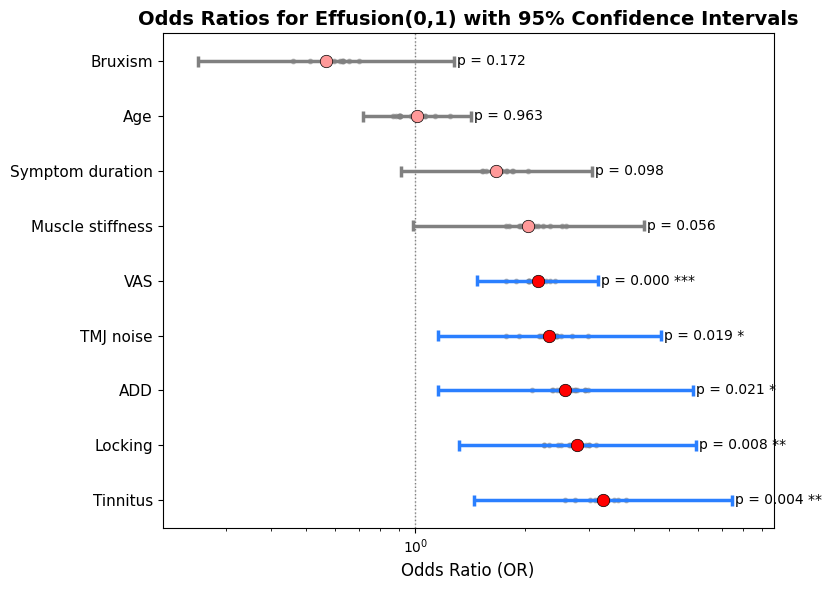

/tmp/ipython-input-3127319812.py:163: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 5.56470102e-01 -1.17328338e+00 -1.11748488e+00  7.79664100e-01
  4.44873103e-01  2.06302958e+00 -5.59499885e-01  1.33764909e+00
  7.23865600e-01 -3.36305888e-01 -8.38492382e-01  1.89563409e+00
 -1.00588788e+00 -1.17328338e+00  2.00723109e+00  1.61664159e+00
  1.00285810e+00  7.23865600e-01  1.65880607e-01 -1.51489139e-03
 -3.36305888e-01 -5.03701386e-01  2.56521608e+00 -1.22908188e+00
 -8.94290881e-01  2.77477605e-01 -3.36305888e-01 -2.24708889e-01
 -8.38492382e-01 -8.94290881e-01 -1.51489139e-03  5.00671603e-01
  5.00671603e-01  1.17025360e+00  7.79664100e-01 -8.94290881e-01
  1.50504459e+00  4.44873103e-01  1.10082107e-01 -1.00588788e+00
  1.65880607e-01 -5.73133907e-02 -1.17328338e+00 -1.11748488e+00
  1.95143259e+00  1.39344759e+00 -1.00588788e+00 -1.00588788e+00
 -1.28488038e+00 -1.39647738e+00 -1.51489139e-03 -6.15298384e-01


[Effusion grade 0/1/2] Ordered Logistic Regression — Proportional OR(95% CI), p
        Variable  B_value  OR_per_grade↑  CI_lower  CI_upper  p_value
             Age   -0.002          0.998     0.767     1.297   0.9856
             ADD    0.739          2.094     1.112     3.941   0.0220
             VAS    0.728          2.071     1.564     2.743   0.0000
Symptom duration   -0.019          0.981     0.768     1.254   0.8806
       TMJ noise    0.581          1.788     1.028     3.110   0.0397
         Locking    0.752          2.122     1.231     3.658   0.0068
Muscle stiffness    0.508          1.662     0.959     2.880   0.0699
        Tinnitus    0.804          2.234     1.280     3.900   0.0047
         Bruxism   -0.386          0.680     0.365     1.268   0.2250


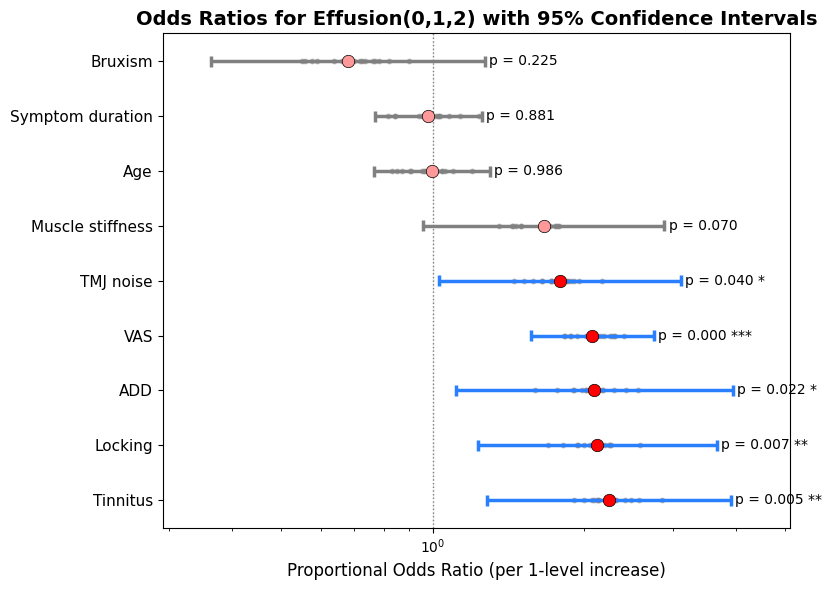

In [11]:
# Outcome 1: Effusion (0/1) → Logistic Regression
# Outcome 2: Effusion grade (0/1/2) → Ordered Logistic Regression
# ====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import StandardScaler

# 가정: df는 이미 로드된 데이터프레임입니다.

# -----------------------
# 0) Predictor 변수
# -----------------------
# [수정] 모델 불안정을 유발할 수 있는 변수('DI', 'PI', 'CMI') 제외
features = ['Age','ADD','VAS','Symptom duration',
            'TMJ noise','Locking','Muscle stiffness','Tinnitus','Bruxism']
features = [c for c in features if c in df.columns]

cont_cols = [c for c in ['Age','VAS','Symptom duration'] if c in features]


# -----------------------
# 유틸: Forest plot 준비
# -----------------------
def _clean_or_table(table: pd.DataFrame, or_col='OR'):
    """결과 테이블에서 유효한 데이터만 필터링하고 정리합니다."""
    t = table.copy()
    if 'Variable' in t.columns:
        t = t[t['Variable']!='const']
    for c in [or_col, 'CI_lower', 'CI_upper'] + (['p_value'] if 'p_value' in t.columns else []):
        t[c] = pd.to_numeric(t[c], errors='coerce')

    m = (np.isfinite(t[or_col]) & np.isfinite(t['CI_lower']) & np.isfinite(t['CI_upper'])
         & (t['CI_lower']>0) & (t['CI_upper']>0))

    dropped = t.loc[~m, 'Variable'].tolist()
    if dropped:
        print('[forest_plot] Dropped (invalid OR/CI values):', dropped)

    t = t.loc[m].copy()
    eps = 1e-6
    t['CI_lower'] = t['CI_lower'].clip(lower=eps)
    t[or_col]     = t[or_col].clip(lower=eps)
    return t

def forest_plot(table, title, or_col='OR', xlab='Odds Ratio (OR)', raw_data_X=None):
    """요청사항이 반영된 맞춤형 Forest Plot을 생성합니다."""
    t = _clean_or_table(table, or_col=or_col)

    t['is_significant'] = t['p_value'] < 0.05
    t = t.sort_values(['is_significant', or_col], ascending=[False, False])

    fig, ax = plt.subplots(figsize=(8.4, 0.5 * len(t) + 1.5))

    # [수정] enumerate를 사용해 0부터 시작하는 순차적인 인덱스 'i'를 y축 위치로 사용
    for i, (idx, row) in enumerate(t.iterrows()):
        is_significant = row['is_significant']

        # p-value에 따른 색상 설정
        ci_color = '#2a7fff' if is_significant else '#808080' # 진한 하늘색 / 진한 회색
        or_color = 'red' if is_significant else '#ff9999'   # 빨간색 / 연한 빨강

        # 95% CI 바와 양 끝 꺾쇠 그리기
        ax.hlines(i, row['CI_lower'], row['CI_upper'], color=ci_color, lw=2.5, zorder=2)
        ax.vlines(row['CI_lower'], i - 0.1, i + 0.1, color=ci_color, lw=2.5, zorder=2)
        ax.vlines(row['CI_upper'], i - 0.1, i + 0.1, color=ci_color, lw=2.5, zorder=2)

        # OR 값 마커
        ax.scatter(row[or_col], i, color=or_color, marker='o', s=80, zorder=3, edgecolors='black', linewidths=0.5)

        # 회색 분포 점 표시
        if raw_data_X is not None and row['Variable'] in raw_data_X.columns:
            if 'B_value' in row.index:
                 b_value = row['B_value']
                 # B값(로그 OR) 주변에 작은 노이즈를 주어 OR 스케일로 변환
                 scatter_x = np.exp(b_value + np.random.normal(0, 0.1, 15))
                 ax.scatter(scatter_x, np.full_like(scatter_x, i),
                            color='gray', s=10, alpha=0.5, zorder=1)

    # OR=1 기준선
    ax.axvline(1, color='gray', linestyle=':', lw=1)

    # Y축 라벨 설정
    ax.set_yticks(np.arange(len(t)))
    ax.set_yticklabels(t['Variable'], fontsize=11)

    # p-value 및 별표 표시
    if 'p_value' in t.columns:
        def stars(p):
            if p < 0.001: return '***'
            elif p < 0.01: return '**'
            elif p < 0.05: return '*'
            else: return ''

        for i, (idx, row) in enumerate(t.iterrows()):
            pv, orv, ciu = row['p_value'], row[or_col], row['CI_upper']
            if np.isfinite(pv):
                text_x_pos = max(orv, ciu) * 1.02
                ax.text(text_x_pos, i, f"p = {pv:.3f} {stars(pv)}",
                        va='center', fontsize=10, color='black')

    ax.set_xlabel(xlab, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xscale('log') # 로그 스케일 유지

    # X축 범위 자동 조정
    xmin = max(0.01, t['CI_lower'].min() * 0.8)
    xmax = t['CI_upper'].max() * 1.3
    if t['OR'].min() < 1 and xmin > t['OR'].min() * 0.5: xmin = t['OR'].min() * 0.5
    if xmax < 2.0: xmax = 2.0

    ax.set_xlim(xmin, xmax)
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    plt.tight_layout()
    plt.show()

# ===========================================================================
# 분석 1) Outcome = Effusion(0/1)
# ===========================================================================
assert 'Effusion' in df.columns, "Effusion(0/1) 컬럼이 필요합니다."
dat1 = df[features + ['Effusion']].dropna().copy()
if cont_cols:
    scaler = StandardScaler()
    dat1.loc[:, cont_cols] = scaler.fit_transform(dat1[cont_cols])

Xb = sm.add_constant(dat1[features], has_constant='add')
y1 = dat1['Effusion'].astype(int)

model1 = sm.Logit(y1, Xb)
try:
    res1 = model1.fit(disp=False)
except Exception:
    res1 = model1.fit_regularized(alpha=0.1, L1_wt=0.0, disp=False)

coef1 = res1.params
pv1 = res1.pvalues
ci1 = res1.conf_int()

tbl1 = pd.DataFrame({
    'Variable': coef1.index,
    'B_value': coef1.values,
    'OR': np.exp(coef1.values),
    'CI_lower': np.exp(ci1.iloc[:, 0].values),
    'CI_upper': np.exp(ci1.iloc[:, 1].values),
    'p_value': pv1.values
}).query("Variable!='const'")

print("\n[Effusion 0/1] Logistic Regression — OR(95% CI), p")
print(tbl1.reset_index(drop=True).round({'B_value':3, 'OR':3,'CI_lower':3,'CI_upper':3,'p_value':4}).to_string(index=False))

forest_plot(tbl1, "Odds Ratios for Effusion(0,1) with 95% Confidence Intervals", raw_data_X=dat1[features])

# ===========================================================================
# 분석 2) Outcome = Effusion grade(0/1/2)
# ===========================================================================
assert 'Effusion grade' in df.columns, "Effusion grade(0/1/2) 컬럼이 필요합니다."
dat2 = df[features + ['Effusion grade']].dropna().copy()
if cont_cols:
    scaler = StandardScaler()
    dat2.loc[:, cont_cols] = scaler.fit_transform(dat2[cont_cols])

Xo = dat2[features]
y2 = dat2['Effusion grade'].astype(int)

model2 = OrderedModel(y2, Xo, distr='logit')
try:
    res2 = model2.fit(method='bfgs', disp=False)
except Exception:
    res2 = model2.fit_regularized(method='l1', alpha=0.1, disp=False)

coef2 = res2.params.filter(items=features)
pv2   = res2.pvalues.filter(items=features)
ci2   = res2.conf_int().filter(items=features, axis=0)

tbl2 = pd.DataFrame({
    'Variable': coef2.index,
    'B_value': coef2.values,
    'OR_per_grade↑': np.exp(coef2.values),
    'CI_lower': np.exp(ci2.iloc[:, 0].values),
    'CI_upper': np.exp(ci2.iloc[:, 1].values),
    'p_value': pv2.values
})

print("\n[Effusion grade 0/1/2] Ordered Logistic Regression — Proportional OR(95% CI), p")
print(tbl2.reset_index(drop=True).round({'B_value':3, 'OR_per_grade↑':3,'CI_lower':3,'CI_upper':3,'p_value':4}).to_string(index=False))

forest_plot(
    tbl2.rename(columns={'OR_per_grade↑':'OR'}),
    "Odds Ratios for Effusion(0,1,2) with 95% Confidence Intervals",
    or_col='OR',
    xlab='Proportional Odds Ratio (per 1-level increase)',
    raw_data_X=dat2[features]
)